In [ ]:
# python

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression



In [4]:
# Load the data

with open('preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
scaler = data['scaler']

# Re-create scaled versions using the already-fitted scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data loaded and scaled!")

Data loaded and scaled!


In [5]:

# ----------------------------------- Train Logistic Regression ---------------------------------------------------------
# class_weight='balanced' compensates for the 75/25 class imbalance
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# Train the model: it learns weights from X_train and y_train
log_reg.fit(X_train_scaled, y_train)

print("Model trained!")

Model trained!


In [6]:
# Let's see the results:

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': log_reg.coef_[0]
}).sort_values('Weight', key=abs, ascending=False)

print(coef_df.to_string(index=False))

             Feature    Weight
      Lactate_mmol_L  1.305181
      Heart_Rate_BPM  1.194120
Arterial_Base_Excess -0.515377
         Injury_Type  0.431154
    Systolic_BP_mmHg  0.141181
Respiratory_Rate_BPM -0.031452
                 Age  0.020972
         Shock_Index -0.007810
                 Sex -0.002724


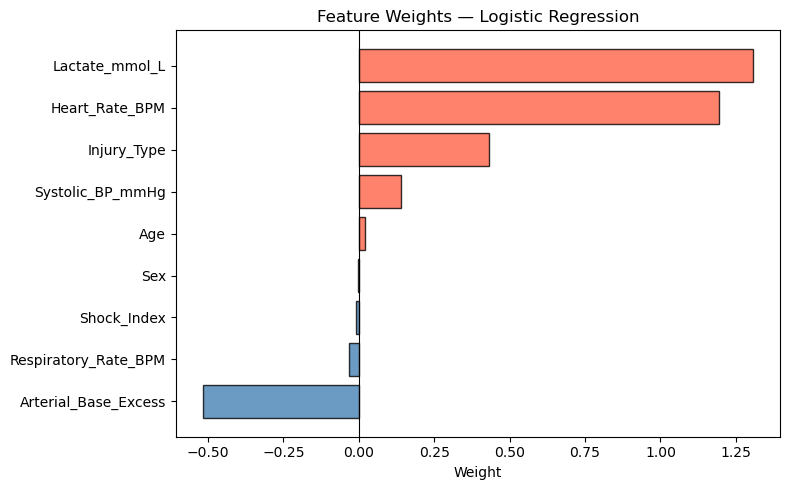

In [15]:
# --------------------------------------------------- Feature Weights — Logistic Regression ---------------------------------------------------------------

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': log_reg.coef_[0]
}).sort_values('Weight', ascending=True)  # ascending for horizontal bar

colors = ['tomato' if w > 0 else 'steelblue' for w in coef_df['Weight']]

plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Weight'], color=colors, edgecolor='black', alpha=0.8)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Weight')
plt.title('Feature Weights — Logistic Regression')
plt.tight_layout()
plt.show()

In [7]:

# Predict on test set
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {auc:.3f}")
print()

# Classification report
print(classification_report(y_test, y_pred, target_names=['Non-MT', 'MT']))
print()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

ROC-AUC: 0.879

              precision    recall  f1-score   support

      Non-MT       0.92      0.84      0.88       150
          MT       0.62      0.78      0.69        50

    accuracy                           0.82       200
   macro avg       0.77      0.81      0.78       200
weighted avg       0.84      0.82      0.83       200


Confusion Matrix:
[[126  24]
 [ 11  39]]


# Cross Validation

In [17]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# ------------------------------------------------- Cross-Validation for Logistic Regression --------------------------------------------------------------------

# StratifiedKFold preserves MT/Non-MT ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ROC-AUC across 5 folds
auc_cv = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC: {auc_cv.mean():.3f} ± {auc_cv.std():.3f}")
print(f"Per fold:   {auc_cv.round(3)}")
print()

# Recall across 5 folds
recall_cv = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='recall')
print(f"CV Recall MT: {recall_cv.mean():.3f} ± {recall_cv.std():.3f}")
print(f"Per fold:     {recall_cv.round(3)}")
print()

# Precision across 5 folds
precision_cv = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='precision')
print(f"CV Precision MT: {precision_cv.mean():.3f} ± {precision_cv.std():.3f}")
print(f"Per fold:        {precision_cv.round(3)}")

CV ROC-AUC: 0.902 ± 0.024
Per fold:   [0.938 0.919 0.867 0.893 0.894]

CV Recall MT: 0.790 ± 0.054
Per fold:     [0.825 0.85  0.725 0.725 0.825]

CV Precision MT: 0.583 ± 0.048
Per fold:        [0.66  0.586 0.569 0.509 0.589]


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])

auc_cv = cross_val_score(pipe, X_train, y_train,
                         cv=cv,
                         scoring='roc_auc')

In [20]:
auc_cv = cross_val_score(
    pipe,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("ROC-AUC for each fold:", auc_cv)
print(f"Mean ROC-AUC: {auc_cv.mean():.3f}")
print(f"Standard deviation: {auc_cv.std():.3f}")

ROC-AUC for each fold: [0.938125   0.919375   0.86708333 0.893125   0.894375  ]
Mean ROC-AUC: 0.902
Standard deviation: 0.024


# The Optimal Thresholds

In [21]:
from sklearn.metrics import roc_curve

# -------------------------------------------------------- Find optimal threshold via Youden Index ----------------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
youden = tpr - fpr
optimal_idx = youden.argmax()
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.3f}")
print()

# Apply optimal threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print("=== Results with optimal threshold ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print()
print(classification_report(y_test, y_pred_optimal, target_names=['Non-MT', 'MT']))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal))

Optimal threshold: 0.527

=== Results with optimal threshold ===
ROC-AUC: 0.879

              precision    recall  f1-score   support

      Non-MT       0.92      0.84      0.88       150
          MT       0.62      0.78      0.69        50

    accuracy                           0.82       200
   macro avg       0.77      0.81      0.78       200
weighted avg       0.84      0.82      0.83       200


Confusion Matrix:
[[126  24]
 [ 11  39]]


In [22]:

# ------------------------------------------Threshold analysis - exploring precision/recall trade-off-----------------------------------------------------------
# Higher threshold = model only says MT when very confident

for t in [0.5, 0.55, 0.6, 0.65, 0.7]:
    y_pred_t = (y_pred_proba >= t).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True)
    recall = report['1']['recall']
    precision = report['1']['precision']
    print(f"threshold={t}: Recall={recall:.2f}, Precision={precision:.2f}")

threshold=0.5: Recall=0.78, Precision=0.62
threshold=0.55: Recall=0.72, Precision=0.61
threshold=0.6: Recall=0.66, Precision=0.60
threshold=0.65: Recall=0.64, Precision=0.59
threshold=0.7: Recall=0.60, Precision=0.64


### The model demonstrates acceptable ROC-AUC on synthetic data, however Precision remains insufficient for clinical deployment. The primary limitation is the synthetic nature of the dataset, which includes an intentional gray zone of overlapping cases. The next step is validation on real clinical data.

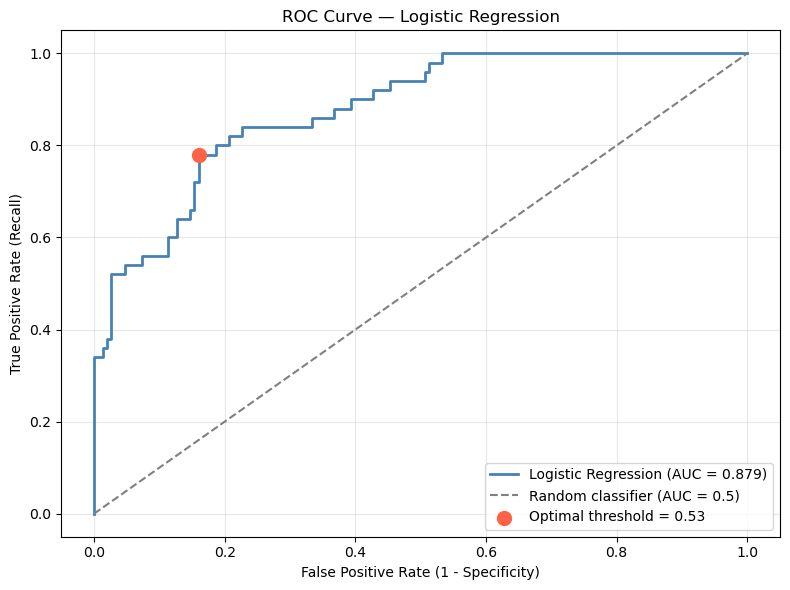

In [23]:
# ------------------------------------------------- ROC Curve for Logistic Regression -------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))

# ROC curve
plt.plot(fpr, tpr, color='steelblue', linewidth=2, 
         label=f'Logistic Regression (AUC = {auc:.3f})')

# Random classifier baseline (diagonal line)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', 
         label='Random classifier (AUC = 0.5)')

# Mark optimal threshold point
optimal_idx = (tpr - fpr).argmax()
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], 
            color='tomato', s=100, zorder=5,
            label=f'Optimal threshold = {thresholds[optimal_idx]:.2f}')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Logistic Regression')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

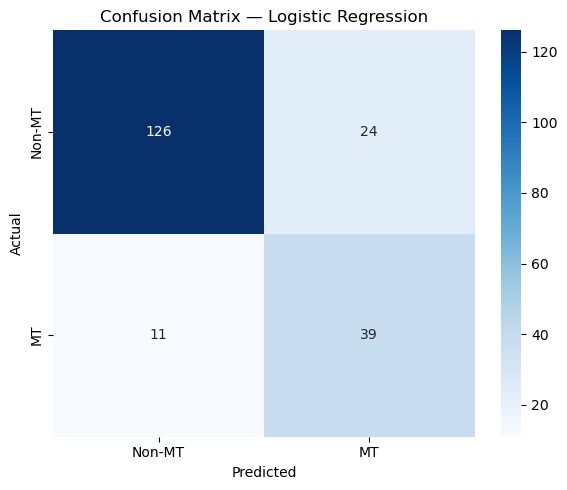

In [24]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-MT', 'MT'],
            yticklabels=['Non-MT', 'MT'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

## Conclusion — Logistic Regression

| Metric | Default (0.50) | Optimal (0.527) |
|--------|---------------|-----------------|
| ROC-AUC | 0.880 | 0.879 |
| Recall MT | 0.78 | 0.78 |
| Precision MT | 0.62 | 0.62 |
| F1 MT | 0.69 | 0.69 |

**Key findings:**
- Logistic Regression is well-calibrated: optimal threshold (0.527) almost identical to default (0.50)
- Lactate and Heart Rate are the strongest predictors — confirmed by model coefficients
- Shock Index shows near-zero weight due to multicollinearity with HR and SBP (SI = HR/SBP)
- Cross-validation confirms stability: CV ROC-AUC = 0.902 ± 0.024, CV Recall = 0.790 ± 0.054
- Model significantly outperforms ABC Score baseline (ROC-AUC 0.880 vs 0.747)
- Precision of 0.62 remains insufficient for clinical deployment
- Primary limitation: synthetic dataset with intentional gray zone
- Next step: validation on real clinical data